# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

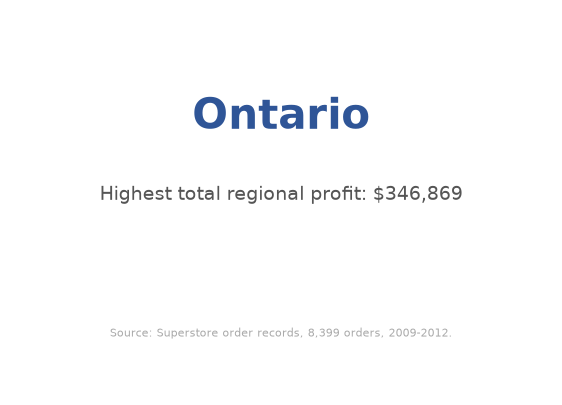

In [2]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()
best_profit = region_totals.max()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# Primary: the decision-relevant result receives the greatest visual weight.
ax.text(
    0.5, 0.72, best_region,
    ha="center", va="center",
    fontsize=30, fontweight="bold", color="#2F5597",
)

# Secondary: the supporting value is readable but visually quieter.
ax.text(
    0.5, 0.52,
    f"Highest total regional profit: ${best_profit:,.0f}",
    ha="center", va="center",
    fontsize=14, fontweight="normal", color="#555555",
)

# Tertiary: source context remains available without competing with the finding.
ax.text(
    0.5, 0.16,
    f"Source: Superstore order records, {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.",
    ha="center", va="center",
    fontsize=8, fontweight="normal", color="#AAAAAA",
)

plt.show()

**Reflection:** My eyes land first on the large blue region name, then on the supporting profit value, and finally on the light-gray source note. A two-second glance should leave the viewer with one fact: Ontario generated the highest total regional profit.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

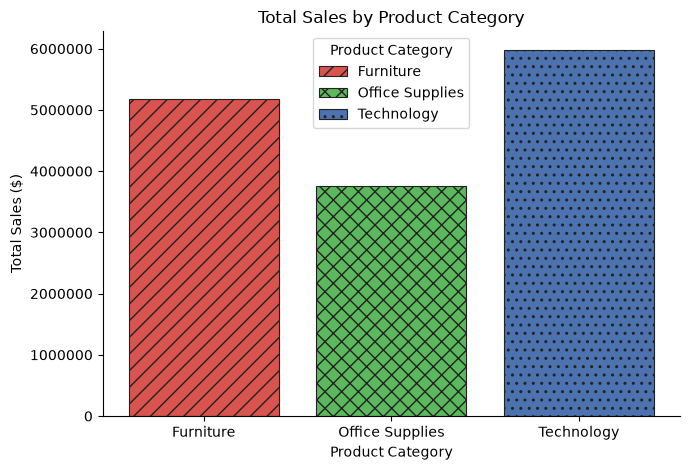

In [3]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

colors = {"Furniture": "#D9534F", "Office Supplies": "#5CB85C", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(7, 4.8))
for cat in cat_sales.index:
    ax.bar(
        cat,
        cat_sales.loc[cat],
        color=colors[cat],
        hatch=hatches[cat],
        edgecolor="#222222",
        linewidth=0.8,
        label=cat,
    )

ax.set_ylabel("Total Sales ($)")
ax.set_xlabel("Product Category")
ax.set_title("Total Sales by Product Category")
ax.legend(title="Product Category")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

**Reflection:** A color-only chart can fail viewers with color-vision deficiencies when hues become hard to distinguish, and it can fail when printed in grayscale because the colors collapse into similar luminance values. The hatch patterns provide a second channel that survives both conditions.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

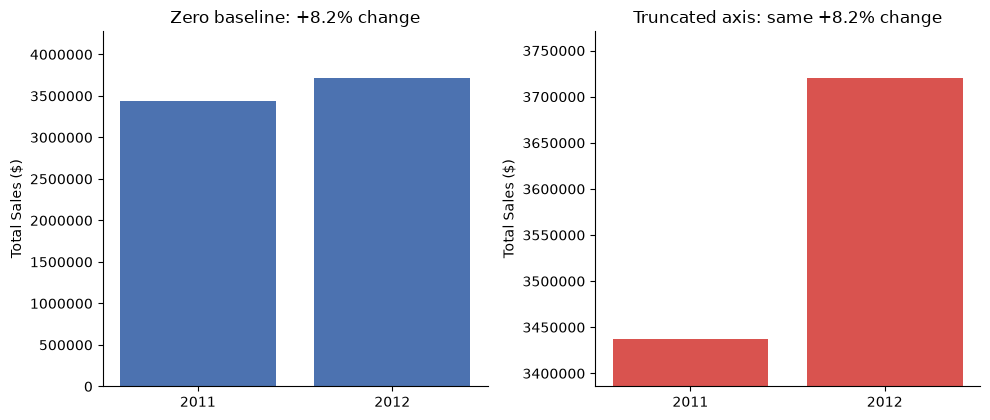

2011 sales: $3,436,816.70
2012 sales: $3,719,963.86
Real change from 2011 to 2012: +8.2%


In [4]:
yearly_sales = sales.groupby("Year")["Sales"].sum().sort_index()

y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.loc[y1], yearly_sales.loc[y2]
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(0, max(v1, v2) * 1.15)
axes[0].set_ylabel("Total Sales ($)")
axes[0].set_title(f"Zero baseline: {pct_change:+.1f}% change")
axes[0].ticklabel_format(style="plain", axis="y")

padding = (max(v1, v2) - min(v1, v2)) * 0.18
axes[1].bar([str(y1), str(y2)], [v1, v2], color="#D9534F")
axes[1].set_ylim(min(v1, v2) - padding, max(v1, v2) + padding)
axes[1].set_ylabel("Total Sales ($)")
axes[1].set_title(f"Truncated axis: same {pct_change:+.1f}% change")
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

print(f"{y1} sales: ${v1:,.2f}")
print(f"{y2} sales: ${v2:,.2f}")
print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:** I would flag the truncated-axis panel if it appeared alone. Its tight vertical range makes the real 8.2% increase look like a dramatic jump, whereas the zero-baseline bar chart communicates the magnitude in proportion to the totals.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales increased 8.2% from 2011 to 2012.
INTERPRETIVE: Sales increased 8.2% in 2012;
the new strategy may have contributed,
but this trend alone does not establish causation.


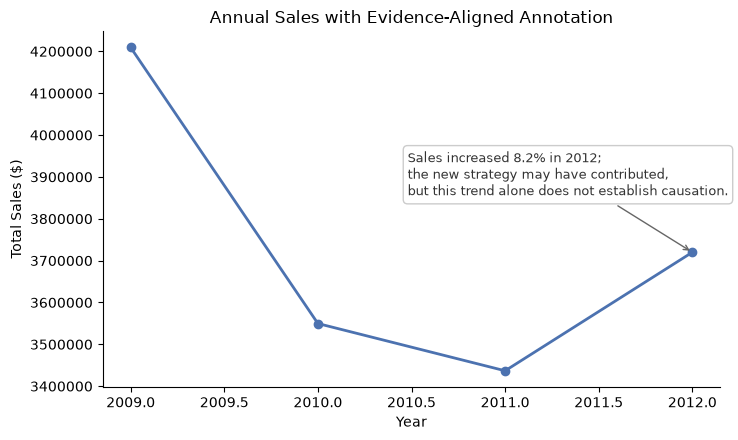

In [5]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

descriptive_version = f"Sales increased {pct_change:.1f}% from {y1} to {y2}."
interpretive_version = (
    f"Sales increased {pct_change:.1f}% in {y2};\n"
    "the new strategy may have contributed,\n"
    "but this trend alone does not establish causation."
)

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0", linewidth=2)
ax.annotate(
    interpretive_version,
    xy=(y2, v2),
    xytext=(-205, 38),
    textcoords="offset points",
    fontsize=9,
    color="#333333",
    ha="left",
    va="bottom",
    arrowprops={"arrowstyle": "->", "color": "#666666"},
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#CCCCCC"},
)
ax.set_xlabel("Year")
ax.set_ylabel("Total Sales ($)")
ax.set_title("Annual Sales with Evidence-Aligned Annotation")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

**Reflection:** The original claim would require causal evidence that isolates the strategy from other explanations. I would want a documented rollout date, a suitable control or comparison group, comparable pre-strategy trends, measurements of promotions and market conditions, and an experimental or credible quasi-experimental analysis showing that the observed lift is unlikely without the strategy.

## Task 5 — The Decision

I consider the truncated headline axis the most urgent fix because it can make an 8.2% increase look like a crisis-sized change to every reader. The Ethical Visualization Audit asks whether the axis and scale honestly represent the magnitude of the difference; the zero-baseline panel passes that check, while the isolated truncated panel does not. The accessibility and hierarchy fixes should also ship so the result remains understandable across viewing conditions. The causal annotation must be replaced with the hedged interpretation because annual sales alone cannot prove why the increase occurred. I recommend requiring a signed five-question ethics audit for every externally published chart, with any non-zero bar baseline or causal annotation explicitly justified by the reviewer.